In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from scipy.optimize import root
from matplotlib.colors import LogNorm

s = Simulation()

In [2]:
import pickle
from pathlib import Path
ROOT = Path.cwd()

# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
wd_range = [0.705 * 2*np.pi, 0.707 * 2*np.pi]
amp_real_range = (0, 1 * 2*np.pi)
amp_imag_range = (0, 1 * 2*np.pi)

# Load coefficients if they exist
if coeff_file.exists():
    with open(coeff_file, 'rb') as f:
        coefficients_data = pickle.load(f)
    coeffs01 = coefficients_data['coeffs01']
    coeffs00 = coefficients_data['coeffs00']
    coeffs11 = coefficients_data['coeffs11']
    coeffs22 = coefficients_data['coeffs22']
    print(f"Coefficients loaded from {coeff_file}")
else:
    N = 40
    coeffs01 = fit_heff_element(s, 0, 1, wd_range, amp_real_range, amp_imag_range, N,N,N, cubic=True)
    coeffs00 = fit_heff_element(s, 0, 0, wd_range, amp_real_range, amp_imag_range, N,N,N, cubic=True)
    coeffs11 = fit_heff_element(s, 1, 1, wd_range, amp_real_range, amp_imag_range, N,N,N, cubic=True)
    coeffs22 = fit_heff_element(s, 2, 2, wd_range, amp_real_range, amp_imag_range, N,N,N, cubic=True)
    # Save coefficients
    coefficients_data = {
        'coeffs01': coeffs01,
        'coeffs00': coeffs00,
        'coeffs11': coeffs11,
        'coeffs22': coeffs22,
    }
    with open(coeff_file, 'wb') as f:
        pickle.dump(coefficients_data, f)
        print(f"Coefficients saved to {coeff_file}")

lcoeff_indices = [[s.state_a,s.state_a], [s.state_b, s.state_b], [s.state_c,s.state_c],
                  [s.state_a,s.state_b]]
lcoeff_names = ['aa', 'bb', 'cc', 'ab']
lcoeffs = [coeffs00, coeffs11, coeffs22,coeffs01]

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = [1, wd, ar, ai, wd**2, ar**2, ai**2,
                wd*ar, wd*ai, ar*ai]
    if not len(coeffs) == 10:
        x.extend([
            wd**3, ar**3, ai**3,
            wd**2*ar, wd**2*ai,
            wd*ar**2, wd*ai**2,
            ar**2*ai, ar*ai**2,
            wd*ar*ai])
    return np.array(x) @ coeffs

Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


Check, how far the heff_element deviation, caused by the fitting is. 

In [3]:
# every combination in the parameter space
N = 30
Nimag = 10
lwd = np.linspace(wd_range[0], wd_range[1], N)
lar = np.linspace(amp_real_range[0], amp_real_range[1], N)
lai = np.linspace(amp_imag_range[0], amp_imag_range[1], Nimag)
deviation_array = np.zeros((len(lcoeffs), N, N, Nimag))
def compute_deviation(idx, coeffs):
    ldeviation = []
    for iwd, wd in enumerate(tqdm(lwd)):
        for iar, ar in enumerate(lar):
            for iai, ai in enumerate(lai):
                deviation = abs(heff_fit(coeffs, wd, ar + 1j*ai) -
                                s.heff_element(*lcoeff_indices[idx], wd, ar + 1j*ai))
                ldeviation.append(deviation)
                deviation_array[idx, iwd, iar, iai] = deviation
    print("max deviation (GHz): ", max(ldeviation), " min: ", min(ldeviation),
        " for coeff: ", lcoeff_names[idx], " indices: ", lcoeff_indices[idx])

for idx, coeffs in enumerate(lcoeffs): 
    compute_deviation(idx, coeffs)

100%|██████████| 30/30 [01:34<00:00,  3.15s/it]


max deviation (GHz):  1.839286327409706e-08  min:  1.4268100589909238e-15  for coeff:  aa  indices:  [1, 1]


100%|██████████| 30/30 [01:39<00:00,  3.31s/it]


max deviation (GHz):  1.209306244032149e-08  min:  1.1035634212008816e-12  for coeff:  bb  indices:  [9, 9]


100%|██████████| 30/30 [01:32<00:00,  3.08s/it]


max deviation (GHz):  1.6188051787935365e-08  min:  6.972200594645983e-13  for coeff:  cc  indices:  [3, 3]


100%|██████████| 30/30 [01:19<00:00,  2.66s/it]

max deviation (GHz):  2.633534361988194e-06  min:  1.1919884309223692e-10  for coeff:  ab  indices:  [1, 9]


In [4]:
# as coeffs12 show high deviation, recompute them
# coeffs12 = fit_heff_element(s, 1,2, wd_range, amp_real_range, amp_imag_range, N,N,N, cubic = True)


/var/folders/7k/3h2gl4fs7gb1hdzh7fl2mc940000gn/T/ipykernel_54243/3953010055.py:4: UserWarning: The following kwargs were not used by contour: 'Levels'
  im = plt.contourf(lwd/(2*np.pi), lar/(2*np.pi), np.maximum(deviation_array[3,:,:,0],1e-20),Levels=100,


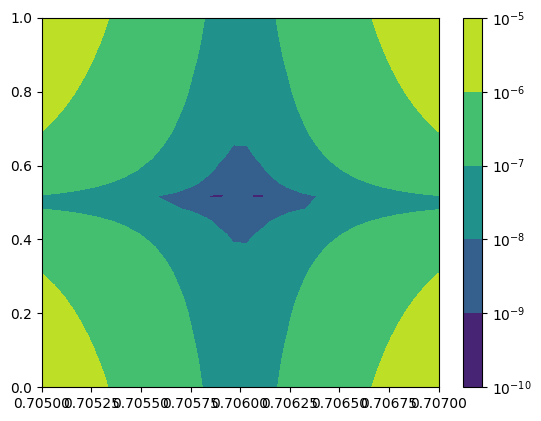

In [ ]:
# compute_deviation(3, coeffs12)

fig, ax_im = plt.subplots()
im = plt.contourf(lwd/(2*np.pi), lar/(2*np.pi), np.maximum(deviation_array[3,:,:,0],1e-20),Levels=100,
                  norm=LogNorm())
plt.colorbar(im)
plt.show()

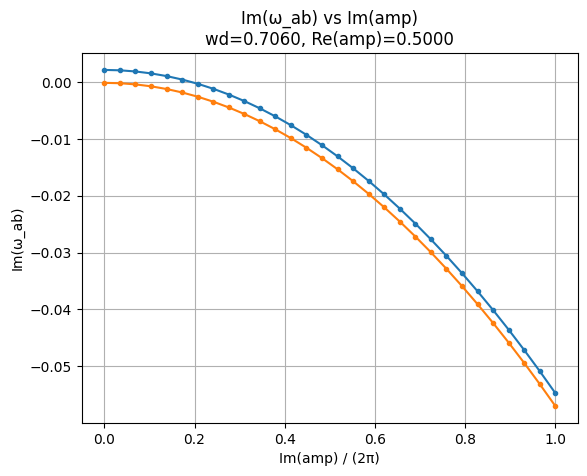

In [6]:
wd_mid = np.mean(wd_range)
amp_real_mid = np.mean(amp_real_range)
ai_vals = np.linspace(amp_imag_range[0], amp_imag_range[1], 200)

omega_ab_im = [np.imag(s.heff_element(s.state_a, s.state_b, wd_mid, amp_real_mid + 1j * ai))
               for ai in ai_vals]
delta_cc = [np.real(s.heff_element(s.state_b, s.state_b, wd_mid, ampr))
               for ampr in lar]
delta_im_cc = [np.real(s.heff_element(s.state_b, s.state_b, wd_mid, 0.2*2*np.pi + 1j*ampi))
               for ampi in lar]

fig, ax_im = plt.subplots()
# ax.plot(ai_vals / (2 * np.pi), omega_ab_im, '-o', markersize=3)
ax_im.plot(lar / (2 * np.pi), delta_cc, '-o', markersize=3)
ax_im.plot(lar / (2 * np.pi), delta_im_cc, '-o', markersize=3, label='im')
ax_im.set_xlabel('Im(amp) / (2π)')
ax_im.set_ylabel('Im(ω_ab)')
ax_im.set_title(f'Im(ω_ab) vs Im(amp)\nwd={wd_mid/(2*np.pi):.4f}, Re(amp)={amp_real_mid/(2*np.pi):.4f}')
ax_im.grid(True)
plt.show()

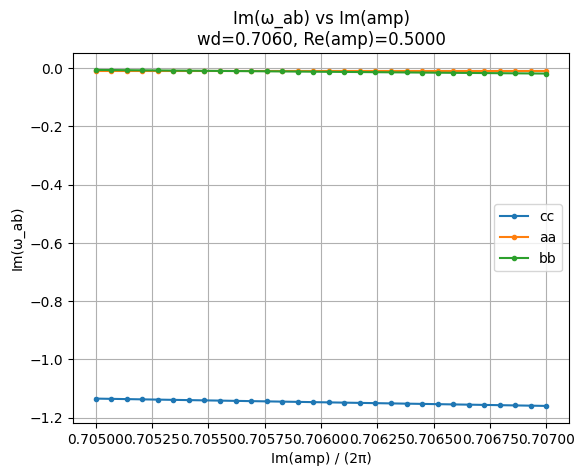

In [7]:
wd_mid = np.mean(wd_range)
amp_real_mid = np.mean(amp_real_range)

delta_cc = [np.real(s.heff_element(s.state_c, s.state_c, wd, amp_real_mid))
               for wd in lwd]
delta_aa = [np.real(s.heff_element(s.state_a, s.state_a, wd, amp_real_mid))
               for wd in lwd]
delta_bb = [np.real(s.heff_element(s.state_b, s.state_b, wd, amp_real_mid))
               for wd in lwd]

fig, ax_im = plt.subplots()
# ax.plot(ai_vals / (2 * np.pi), omega_ab_im, '-o', markersize=3)
ax_im.plot(lwd / (2 * np.pi), delta_cc, '-o', markersize=3, label='cc')
ax_im.plot(lwd / (2 * np.pi), delta_aa, '-o', markersize=3, label='aa')
ax_im.plot(lwd / (2 * np.pi), delta_bb, '-o', markersize=3, label='bb')
plt.legend()
ax_im.set_xlabel('Im(amp) / (2π)')
ax_im.set_ylabel('Im(ω_ab)')
ax_im.set_title(f'Im(ω_ab) vs Im(amp)\nwd={wd_mid/(2*np.pi):.4f}, Re(amp)={amp_real_mid/(2*np.pi):.4f}')
ax_im.grid(True)
plt.show()

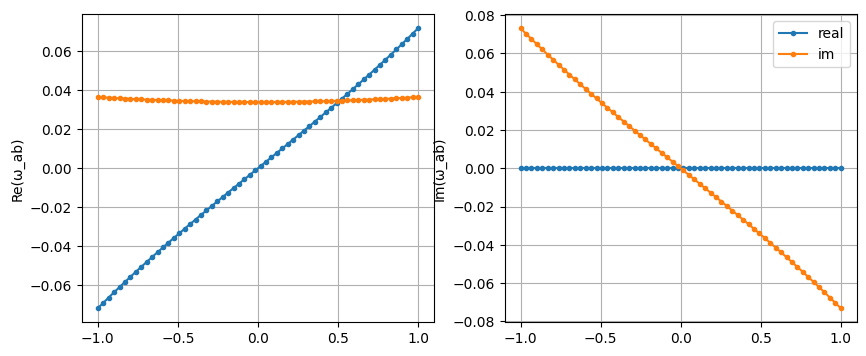

In [8]:
wd_mid = np.mean(wd_range)
amp_real_mid = np.mean(amp_real_range)
ai_vals = np.linspace(amp_imag_range[0], amp_imag_range[1], 100)

lar = np.linspace(-amp_real_range[1], amp_real_range[1], 2*N)

omega_ab_im_im = [np.imag(s.heff_element(s.state_a, s.state_b, wd_mid, amp_real_mid + 1j * ai))
               for ai in lar]
omega_ab_im_real = [np.imag(s.heff_element(s.state_a, s.state_b, wd_mid, ar))
               for ar in lar]

omega_ab_r_im = [np.real(s.heff_element(s.state_a, s.state_b, wd_mid, amp_real_mid + 1j * ai))
               for ai in lar]
omega_ab_r_r = [np.real(s.heff_element(s.state_a, s.state_b, wd_mid, ar))
               for ar in lar]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# ax.plot(ai_vals / (2 * np.pi), omega_ab_im, '-o', markersize=3)
ax_im = axes[1]
ax_real = axes[0]
ax_im.plot(lar / (2 * np.pi), omega_ab_im_real, '-o', markersize=3, label='real')
ax_im.plot(lar / (2 * np.pi), omega_ab_im_im, '-o', markersize=3, label='im')
ax_im.set_ylabel('Im(ω_ab)')
ax_im.grid(True)
ax_real.plot(lar / (2 * np.pi), omega_ab_r_r, '-o', markersize=3, label='real')
ax_real.plot(lar / (2 * np.pi), omega_ab_r_im, '-o', markersize=3, label='im')
ax_real.set_ylabel('Re(ω_ab)')
ax_real.grid(True)
plt.legend()
plt.show()